Installation, chargement, vérification de propreté

In [ ]:
!pip install catboost shap xgboost --quiet

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import time

base = '/content/drive/MyDrive/EnergyMind_TSYP14/data/'
df_full = pd.read_csv(base + 'quartier_avec_anomalies.csv', parse_dates=['tstp'])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
DATE_SPLIT = pd.Timestamp('2013-11-28')
df_full['split'] = np.where(df_full['tstp'] < DATE_SPLIT, 'train', 'test')
df_full['heure'] = df_full['tstp'].dt.hour
df_full['jour_semaine'] = df_full['tstp'].dt.dayofweek

# EXCLUSION explicite des vrais trous (jamais d'imputation à 0)
df_full = df_full.dropna(subset=['energy(kWh/hh)', 'Voltage', 'Global_intensity']).reset_index(drop=True)
print("Lignes conservées après exclusion des vrais trous :", df_full.shape)

df_train_ref = df_full[(df_full['split'] == 'train') & (df_full['anomaly_type'] == 'none')]

def baseline_robuste(df_ref, colonne):
    b = df_ref.groupby(['LCLid', 'heure', 'jour_semaine'])[colonne].agg(
        mediane='median', mad=lambda x: (x - x.median()).abs().median(), n='count'
    ).reset_index()
    secours = df_ref.groupby(['LCLid', 'heure'])[colonne].agg(
        mediane_s='median', mad_s=lambda x: (x - x.median()).abs().median()
    ).reset_index()
    b = b.merge(secours, on=['LCLid', 'heure'], how='left')
    b['mediane'] = np.where(b['n'] < 15, b['mediane_s'], b['mediane'])
    b['mad'] = np.where(b['n'] < 15, b['mad_s'], b['mad'])
    return b[['LCLid', 'heure', 'jour_semaine', 'mediane', 'mad']].rename(
        columns={'mediane': f'mediane_{colonne}', 'mad': f'mad_{colonne}'})

base_energy = baseline_robuste(df_train_ref, 'energy(kWh/hh)')
base_voltage = baseline_robuste(df_train_ref, 'Voltage')

df_full = df_full.merge(base_energy, on=['LCLid', 'heure', 'jour_semaine'], how='left')
df_full = df_full.merge(base_voltage, on=['LCLid', 'heure', 'jour_semaine'], how='left')

df_full['z_energy'] = (df_full['energy(kWh/hh)'] - df_full['mediane_energy(kWh/hh)']) / (1.4826 * df_full['mad_energy(kWh/hh)'].replace(0, np.nan))
df_full['z_voltage'] = (df_full['Voltage'] - df_full['mediane_Voltage']) / (1.4826 * df_full['mad_Voltage'].replace(0, np.nan))

# Plafonnement LARGE (garde-fou anti-division par ~0), pas un plafond qui écrase le signal réel
df_full['z_energy'] = df_full['z_energy'].clip(-80, 80)
df_full['z_voltage'] = df_full['z_voltage'].clip(-80, 80)

print(df_full[['z_energy', 'z_voltage']].describe())

Lignes conservées après exclusion des vrais trous : (951249, 25)
            z_energy      z_voltage
count  951249.000000  951249.000000
mean        1.479818       0.059383
std         8.353028       1.298875
min       -80.000000      -7.186012
25%        -0.591900      -0.674960
50%         0.025114       0.007132
75%         0.959555       0.698625
max        80.000000      14.914575


In [ ]:
def construire_features(df):
    df = df.sort_values(['LCLid', 'tstp']).copy()
    g_energy = df.groupby('LCLid')['energy(kWh/hh)']
    g_voltage = df.groupby('LCLid')['Voltage']

    for fenetre, nom in [(6, '3h'), (48, '1j'), (336, '7j')]:
        df[f'roll_mean_energy_{nom}'] = g_energy.transform(lambda x: x.rolling(fenetre, min_periods=1).mean())
        df[f'roll_std_energy_{nom}'] = g_energy.transform(lambda x: x.rolling(fenetre, min_periods=1).std())
        df[f'roll_mean_voltage_{nom}'] = g_voltage.transform(lambda x: x.rolling(fenetre, min_periods=1).mean())
        df[f'roll_std_voltage_{nom}'] = g_voltage.transform(lambda x: x.rolling(fenetre, min_periods=1).std())

    for decalage, nom in [(1, '30min'), (48, '1j'), (336, '7j')]:
        df[f'lag_energy_{nom}'] = g_energy.transform(lambda x: x.shift(decalage))

    df['diff_energy_1'] = g_energy.transform(lambda x: x.diff())
    df['diff_voltage_1'] = g_voltage.transform(lambda x: x.diff())

    def longueur_plage_figee(x):
        eg = (x.diff() == 0)
        groupes = (eg != eg.shift()).cumsum()
        return eg.groupby(groupes).cumsum()
    df['longueur_plage_figee'] = g_energy.transform(longueur_plage_figee)

    df['S_calculee'] = (df['Voltage'] * df['Global_intensity']) / 1000
    ecart_baseline = df[(df['split'] == 'train') & (df['anomaly_type'] == 'none')].groupby('LCLid').apply(
        lambda x: (x['power_kW'] - x['S_calculee']).abs().median())
    df['ecart_physique_baseline'] = df['LCLid'].map(ecart_baseline)
    df['ecart_physique_relatif'] = (df['power_kW'] - df['S_calculee']).abs() - df['ecart_physique_baseline']

    df['vague_extreme'] = ((df['Temperature_synth'] > 32) | (df['Temperature_synth'] < 5)).astype(int)
    df['est_weekend'] = (df['jour_semaine'] >= 5).astype(int)
    return df

df_full = construire_features(df_full)

FEATURES = ['energy(kWh/hh)', 'Voltage', 'Global_intensity', 'Temperature_synth', 'Humidity_synth',
            'heure', 'jour_semaine', 'est_weekend', 'vague_extreme',
            'roll_mean_energy_3h', 'roll_std_energy_3h', 'roll_mean_energy_1j', 'roll_std_energy_1j',
            'roll_mean_energy_7j', 'roll_std_energy_7j',
            'roll_mean_voltage_3h', 'roll_std_voltage_3h', 'roll_mean_voltage_1j', 'roll_std_voltage_1j',
            'roll_mean_voltage_7j', 'roll_std_voltage_7j',
            'lag_energy_30min', 'lag_energy_1j', 'lag_energy_7j', 'diff_energy_1', 'diff_voltage_1',
            'z_energy', 'z_voltage', 'ecart_physique_relatif', 'longueur_plage_figee',
            'fraction_foyers_extremes']

df_full = df_full.dropna(subset=['lag_energy_7j']).reset_index(drop=True)
df_train = df_full[df_full['split'] == 'train'].reset_index(drop=True)
df_test = df_full[df_full['split'] == 'test'].reset_index(drop=True)
print(df_train.shape, df_test.shape)
print(df_train[FEATURES].isna().sum().sum(), "NaN restants (doit être 0)")

/tmp/ipykernel_1309/1788996950.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ecart_baseline = df[(df['split'] == 'train') & (df['anomaly_type'] == 'none')].groupby('LCLid').apply(


(756864, 54) (180609, 54)
0 NaN restants (doit être 0)


In [ ]:
def ajouter_features_persistance(df):
    g = df.groupby('LCLid')['z_energy']
    df['roll_mean_z_1j'] = g.transform(lambda x: x.rolling(48, min_periods=1).mean())
    df['roll_std_z_1j'] = g.transform(lambda x: x.rolling(48, min_periods=1).std())
    # Ratio clé : un décalage soutenu garde une moyenne glissante élevée ET un écart-type faible
    # (tout le monde est décalé pareil) ; un pic isolé fait l'inverse (moyenne diluée, écart-type élevé)
    df['ratio_persistance'] = df['roll_mean_z_1j'].abs() / (df['roll_std_z_1j'] + 1e-3)
    return df

df_full = ajouter_features_persistance(df_full)
FEATURES = FEATURES + ['roll_mean_z_1j', 'roll_std_z_1j', 'ratio_persistance']

df_train = df_full[df_full['split'] == 'train'].reset_index(drop=True)
df_test = df_full[df_full['split'] == 'test'].reset_index(drop=True)
print("Nouvelles features ajoutées :", ['roll_mean_z_1j', 'roll_std_z_1j', 'ratio_persistance'])

Nouvelles features ajoutées : ['roll_mean_z_1j', 'roll_std_z_1j', 'ratio_persistance']


In [ ]:
VAL_START = pd.Timestamp('2013-10-01')

df_train['sous_split'] = np.where(df_train['tstp'] < VAL_START, 'sub_train', 'val')
print(df_train['sous_split'].value_counts())
print(df_train.groupby('sous_split')['anomaly_type'].apply(lambda x: (x != 'none').mean()))

sous_split
sub_train    642760
val          114104
Name: count, dtype: int64
sous_split
sub_train    0.061301
val          0.050165
Name: anomaly_type, dtype: float64


Règle statistique multi-canal (énergie + tension)

In [ ]:
mask_normal_train = df_train['anomaly_type'] == 'none'
seuil_z_energy = df_train.loc[mask_normal_train, 'z_energy'].abs().quantile(0.99)
seuil_z_voltage = df_train.loc[mask_normal_train, 'z_voltage'].abs().quantile(0.99)
seuil_figee = 8

print(f"Seuils calibrés : z_energy={seuil_z_energy:.2f}, z_voltage={seuil_z_voltage:.2f}")

def appliquer_regle(df):
    c1 = df['z_energy'].abs() > seuil_z_energy
    c2 = df['z_voltage'].abs() > seuil_z_voltage
    c3 = df['longueur_plage_figee'] >= seuil_figee
    return c1 | c2 | c3

pred_test_regle = appliquer_regle(df_test)

Seuils calibrés : z_energy=24.59, z_voltage=2.92


Fonctions d'évaluation complètes avec visualisations

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix,
                              roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
                              ConfusionMatrixDisplay, classification_report)

def evaluer_binaire(y_vrai, y_pred, y_score=None, nom=""):
    p = precision_score(y_vrai, y_pred, zero_division=0)
    r = recall_score(y_vrai, y_pred, zero_division=0)
    f1 = f1_score(y_vrai, y_pred, zero_division=0)
    print(f"[{nom}] précision={p:.3f}  rappel={r:.3f}  F1={f1:.3f}")

    fig, axes = plt.subplots(1, 3 if y_score is not None else 1, figsize=(15, 4))
    if y_score is None:
        axes = [axes]

    cm = confusion_matrix(y_vrai, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomalie']).plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f"Matrice de confusion — {nom}")

    if y_score is not None:
        fpr, tpr, _ = roc_curve(y_vrai, y_score)
        auc = roc_auc_score(y_vrai, y_score)
        axes[1].plot(fpr, tpr, label=f"AUC={auc:.3f}")
        axes[1].plot([0, 1], [0, 1], '--', color='gray')
        axes[1].set_xlabel("Taux de faux positifs"); axes[1].set_ylabel("Taux de vrais positifs")
        axes[1].set_title("Courbe ROC"); axes[1].legend()

        prec, rec, _ = precision_recall_curve(y_vrai, y_score)
        ap = average_precision_score(y_vrai, y_score)
        axes[2].plot(rec, prec, label=f"AP={ap:.3f}")
        axes[2].set_xlabel("Rappel"); axes[2].set_ylabel("Précision")
        axes[2].set_title("Courbe Précision-Rappel"); axes[2].legend()

    plt.tight_layout(); plt.show()
    return {'precision': p, 'rappel': r, 'f1': f1}

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix,
                              roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
                              ConfusionMatrixDisplay, classification_report)


def evaluer_binaire(y_vrai, y_pred, y_score, nom):
    p = precision_score(y_vrai, y_pred, zero_division=0)
    r = recall_score(y_vrai, y_pred, zero_division=0)
    f1 = f1_score(y_vrai, y_pred, zero_division=0)
    print(f"[{nom}] précision={p:.3f}  rappel={r:.3f}  F1={f1:.3f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    cm = confusion_matrix(y_vrai, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomalie']).plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f"Matrice de confusion — {nom}")

    fpr, tpr, _ = roc_curve(y_vrai, y_score)
    auc = roc_auc_score(y_vrai, y_score)
    axes[1].plot(fpr, tpr, label=f"AUC={auc:.3f}")
    axes[1].plot([0, 1], [0, 1], '--', color='gray')
    axes[1].set_xlabel("Taux de faux positifs"); axes[1].set_ylabel("Taux de vrais positifs")
    axes[1].set_title("Courbe ROC"); axes[1].legend()

    prec, rec, _ = precision_recall_curve(y_vrai, y_score)
    ap = average_precision_score(y_vrai, y_score)
    axes[2].plot(rec, prec, label=f"AP={ap:.3f}")
    axes[2].set_xlabel("Rappel"); axes[2].set_ylabel("Précision")
    axes[2].set_title("Courbe Précision-Rappel"); axes[2].legend()

    plt.tight_layout(); plt.show()
    return {'precision': p, 'rappel': r, 'f1': f1, 'auc': auc, 'ap': ap}


def seuil_par_fpr_cible(y_val, proba_val, fpr_cible=0.05):
    fpr, tpr, seuils = roc_curve(y_val, proba_val)
    idx = np.argmin(np.abs(fpr - fpr_cible))
    return seuils[idx], fpr[idx], tpr[idx]


def entrainer_comparer_optimiser(X_sub, y_sub, X_val, y_val, X_test, y_test,
                                  type_tache, noms_classes=None, poids_sub=None, nom_but="",
                                  seuil_par_fpr=None):
    X_opt = pd.concat([X_sub, X_val])
    y_opt = np.concatenate([y_sub, y_val])
    test_fold = np.concatenate([np.full(len(X_sub), -1), np.full(len(X_val), 0)])
    split_predefini = PredefinedSplit(test_fold)
    poids_opt = np.concatenate([poids_sub, np.ones(len(X_val))]) if poids_sub is not None else None

    # --- XGBoost ---
    grille_xgb = {'max_depth': [4, 6, 8], 'learning_rate': [0.05, 0.1], 'n_estimators': [200, 400]}
    base_xgb = XGBClassifier(
        random_state=42, n_jobs=-1,
        eval_metric='mlogloss' if type_tache == 'multiclasse' else 'logloss',
        objective='multi:softprob' if type_tache == 'multiclasse' else 'binary:logistic',
        num_class=len(noms_classes) if type_tache == 'multiclasse' else None)
    recherche_xgb = RandomizedSearchCV(base_xgb, grille_xgb, n_iter=4, cv=split_predefini,
                                        scoring='f1_macro' if type_tache == 'multiclasse' else 'f1', random_state=42)
    recherche_xgb.fit(X_opt, y_opt, sample_weight=poids_opt)
    xgb_final = recherche_xgb.best_estimator_
    print(f"[{nom_but}] Meilleurs paramètres XGBoost :", recherche_xgb.best_params_)

    # --- CatBoost ---
    grille_cat = {'depth': [4, 6, 8], 'learning_rate': [0.05, 0.1], 'iterations': [200, 400]}
    base_cat = CatBoostClassifier(random_seed=42, verbose=0)
    recherche_cat = RandomizedSearchCV(base_cat, grille_cat, n_iter=4, cv=split_predefini,
                                        scoring='f1_macro' if type_tache == 'multiclasse' else 'f1', random_state=42)
    recherche_cat.fit(X_opt, y_opt)
    cat_final = recherche_cat.best_estimator_
    print(f"[{nom_but}] Meilleurs paramètres CatBoost :", recherche_cat.best_params_)

    # Ré-entraînement propre sur sub_train uniquement (jamais sur val)
    xgb_final.fit(X_sub, y_sub, sample_weight=poids_sub)
    cat_final.fit(X_sub, y_sub)

    # --- Random Forest ---
    rf_final = RandomForestClassifier(n_estimators=400, max_depth=10, class_weight='balanced',
                                       random_state=42, n_jobs=-1)
    rf_final.fit(X_sub, y_sub, sample_weight=poids_sub)

    # --- Ensembles ---
    ensemble_vote = VotingClassifier(estimators=[('xgb', xgb_final), ('cat', cat_final)], voting='soft')
    ensemble_vote.fit(X_sub, y_sub)

    ensemble_stack = StackingClassifier(estimators=[('xgb', xgb_final), ('cat', cat_final)],
                                         final_estimator=LogisticRegression(max_iter=1000), cv=5)
    ensemble_stack.fit(X_sub, y_sub)

    candidats = {'XGBoost': xgb_final, 'CatBoost': cat_final, 'Random Forest': rf_final,
                 'Soft Voting': ensemble_vote, 'Stacking': ensemble_stack}

    # --- Sélection sur validation ---
    scores_val = {}
    for nom, modele in candidats.items():
        pred_val = modele.predict(X_val)
        score = f1_score(y_val, pred_val, average='macro' if type_tache == 'multiclasse' else 'binary', zero_division=0)
        scores_val[nom] = score
    print(f"\n[{nom_but}] Scores F1 sur validation :", {k: round(v, 3) for k, v in scores_val.items()})
    meilleur_nom = max(scores_val, key=scores_val.get)
    print(f"[{nom_but}] Modèle retenu : {meilleur_nom}")

    # --- Calibration du seuil (binaire uniquement) ---
    seuil_optimal = 0.5
    if type_tache == 'binaire':
        proba_val = candidats[meilleur_nom].predict_proba(X_val)[:, 1]
        if seuil_par_fpr is not None:
            seuil_optimal, fpr_obt, tpr_obt = seuil_par_fpr_cible(y_val, proba_val, seuil_par_fpr)
            print(f"[{nom_but}] Seuil calibré par FPR cible={seuil_par_fpr} : {seuil_optimal:.3f} "
                  f"(FPR obtenu={fpr_obt:.3f}, TPR obtenu={tpr_obt:.3f})")
        else:
            seuils_essai = np.linspace(0.05, 0.95, 50)
            f1s = [f1_score(y_val, proba_val > s, zero_division=0) for s in seuils_essai]
            seuil_optimal = seuils_essai[np.argmax(f1s)]
            print(f"[{nom_but}] Seuil optimal (F1) calibré sur validation : {seuil_optimal:.2f}")

    # --- Évaluation finale sur TEST ---
    if type_tache == 'binaire':
        proba_test = candidats[meilleur_nom].predict_proba(X_test)[:, 1]
        pred_test = proba_test > seuil_optimal
        resultats_test = evaluer_binaire(y_test, pred_test, proba_test,
                                          f"{nom_but} — {meilleur_nom} (seuil={seuil_optimal:.3f})")
    else:
        pred_test = candidats[meilleur_nom].predict(X_test)
        print(f"\n=== {nom_but} — TEST (modèle : {meilleur_nom}) ===")
        print(classification_report(y_test, pred_test, target_names=noms_classes, zero_division=0))
        cm = confusion_matrix(y_test, pred_test)
        ConfusionMatrixDisplay(cm, display_labels=noms_classes).plot(xticks_rotation=45, cmap='Blues', colorbar=False)
        plt.title(f"Matrice de confusion — {nom_but}"); plt.tight_layout(); plt.show()
        resultats_test = classification_report(y_test, pred_test, target_names=noms_classes,
                                                zero_division=0, output_dict=True)

    # --- SHAP (sur XGBoost, toujours disponible même si un autre modèle est retenu) ---
    echantillon = X_test.sample(min(500, len(X_test)), random_state=42)
    explainer = shap.TreeExplainer(xgb_final)
    shap_values = explainer.shap_values(echantillon)
    shap.summary_plot(shap_values, echantillon, max_display=12,
                       class_names=noms_classes if type_tache == 'multiclasse' else None, show=True)

    return candidats, meilleur_nom, seuil_optimal, resultats_test

Étage A : Harness générique réutilisable (XGB, CatBoost, soft voting, stacking, sélection + optimisation)

Répartition — sub_train: 0.06130126330201008  val: 0.050164761971534744  test: 0.053784695114861385
[Étage A — Détection globale] Meilleurs paramètres XGBoost : {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05}
[Étage A — Détection globale] Meilleurs paramètres CatBoost : {'learning_rate': 0.05, 'iterations': 400, 'depth': 8}

[Étage A — Détection globale] Scores F1 sur validation : {'XGBoost': 0.626, 'CatBoost': 0.705, 'Random Forest': 0.095, 'Soft Voting': 0.703, 'Stacking': 0.68}
[Étage A — Détection globale] Modèle retenu : CatBoost
[Étage A — Détection globale] Seuil optimal (F1) calibré sur validation : 0.34
[Étage A — Détection globale — CatBoost (seuil=0.344)] précision=0.919  rappel=0.506  F1=0.653


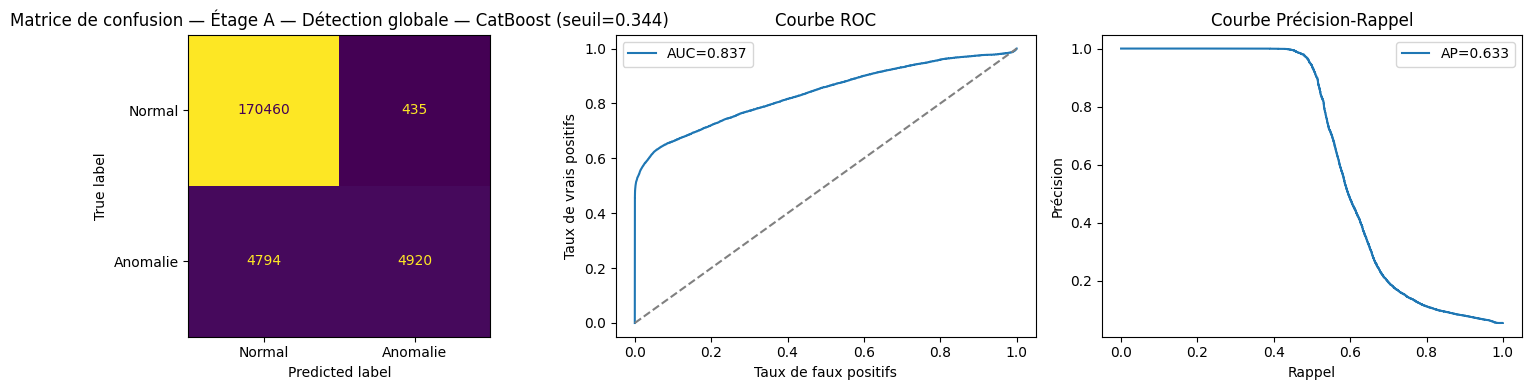

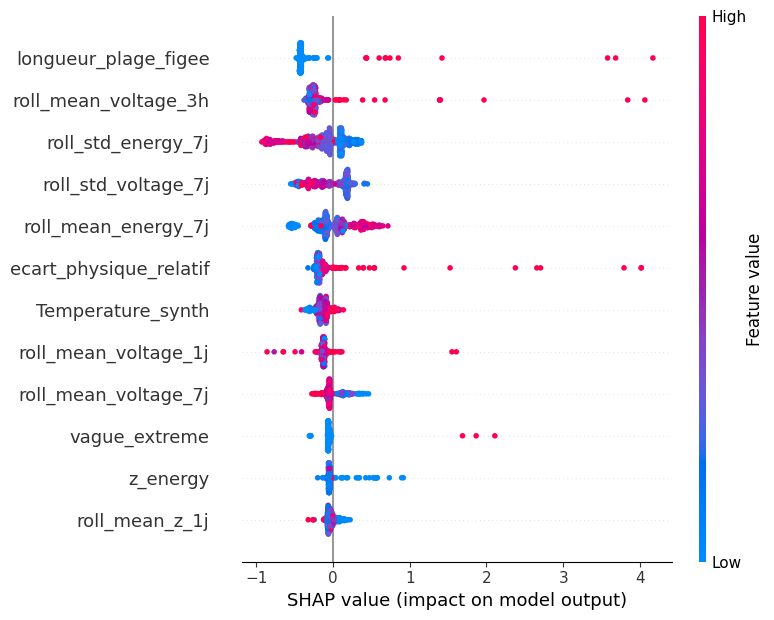

In [ ]:
mask_sub_A = df_train['sous_split'] == 'sub_train'
mask_val_A = df_train['sous_split'] == 'val'

X_sub_A = df_train.loc[mask_sub_A, FEATURES]
y_sub_A = (df_train.loc[mask_sub_A, 'anomaly_type'] != 'none').astype(int)
X_val_A = df_train.loc[mask_val_A, FEATURES]
y_val_A = (df_train.loc[mask_val_A, 'anomaly_type'] != 'none').astype(int)
X_test_A = df_test[FEATURES]
y_test_A = (df_test['anomaly_type'] != 'none').astype(int)

poids_A = compute_sample_weight('balanced', y_sub_A)

print("Répartition — sub_train:", y_sub_A.mean(), " val:", y_val_A.mean(), " test:", y_test_A.mean())

candidats_A, meilleur_A, seuil_A, resultats_A = entrainer_comparer_optimiser(
    X_sub_A, y_sub_A, X_val_A, y_val_A, X_test_A, y_test_A,
    type_tache='binaire', poids_sub=poids_A, nom_but="Étage A — Détection globale")

In [ ]:
# Diagnostic : rappel décomposé par type réel d'anomalie
df_test_diag = df_test.copy()
df_test_diag['proba_A'] = candidats_A[meilleur_A].predict_proba(df_test_diag[FEATURES])[:, 1]
df_test_diag['pred_A'] = df_test_diag['proba_A'] > seuil_A

print("Taux de détection (rappel) par type d'anomalie, Étage A :")
print(df_test_diag[df_test_diag['anomaly_type'] != 'none'].groupby('anomaly_type')['pred_A'].mean().sort_values())

Taux de détection (rappel) par type d'anomalie, Étage A :
anomaly_type
biased_reading         0.025529
genuine_event          0.372807
corrupted_falsified    0.477054
natural_failure        0.801056
degraded_sensor        0.831067
equipment_fault        0.927621
Name: pred_A, dtype: float64


Étage B : discrimination genuine_event vs data-quality (parmi les vraies anomalies)

In [ ]:
# Répartition temporelle des 12 épisodes genuine_event, pour vérifier le déséquilibre entre splits
episodes_genuine = df_full[df_full['anomaly_type'] == 'genuine_event'].groupby('anomaly_id')['tstp'].min().sort_values()
print(episodes_genuine)

anomaly_id
4030.0   2012-11-16 10:30:00
4032.0   2012-12-04 23:30:00
4033.0   2013-01-10 17:00:00
4036.0   2013-02-01 10:30:00
4025.0   2013-02-14 23:00:00
4028.0   2013-08-05 03:00:00
4026.0   2013-10-27 21:00:00
4031.0   2013-10-30 07:30:00
4035.0   2013-11-08 16:30:00
4029.0   2013-11-20 06:30:00
4034.0   2013-12-05 14:30:00
4027.0   2014-01-16 13:00:00
Name: tstp, dtype: datetime64[ns]


Effectifs anomalies — sub_train: 39402  val: 5724  test: 9714
Taux genuine_event — sub_train: 0.043525709354855086  val: 0.17365478686233404  test: 0.04694255713403336
[Étage B — Genuine vs Data-Quality] Meilleurs paramètres XGBoost : {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05}
[Étage B — Genuine vs Data-Quality] Meilleurs paramètres CatBoost : {'learning_rate': 0.05, 'iterations': 200, 'depth': 4}

[Étage B — Genuine vs Data-Quality] Scores F1 sur validation : {'XGBoost': 0.31, 'CatBoost': 0.351, 'Random Forest': 0.493, 'Soft Voting': 0.306, 'Stacking': 0.305}
[Étage B — Genuine vs Data-Quality] Modèle retenu : Random Forest
[Étage B — Genuine vs Data-Quality] Seuil calibré par FPR cible=0.05 : 0.866 (FPR obtenu=0.050, TPR obtenu=0.476)
[Étage B — Genuine vs Data-Quality — Random Forest (seuil=0.866)] précision=0.192  rappel=0.246  F1=0.216


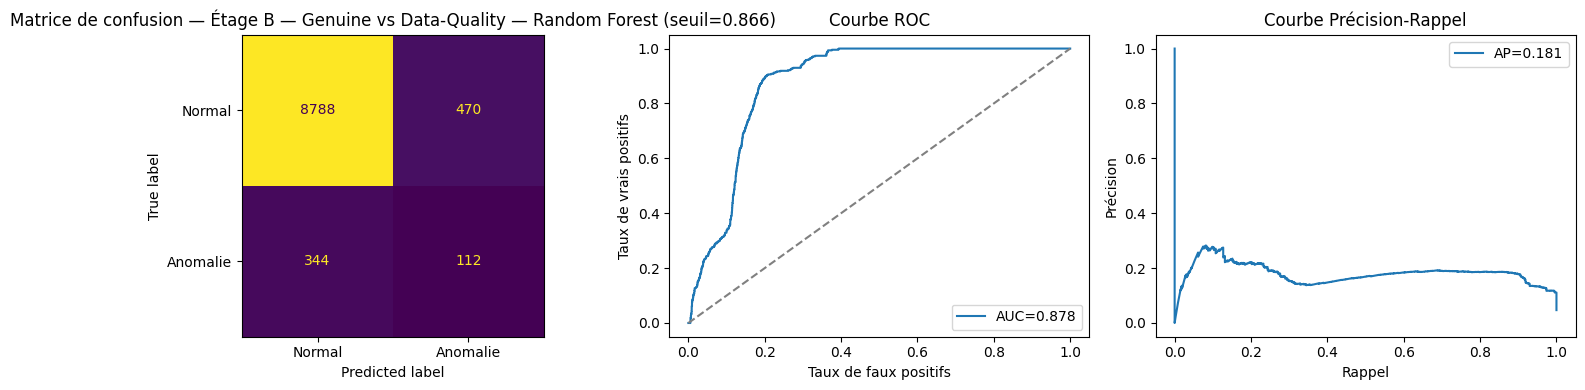

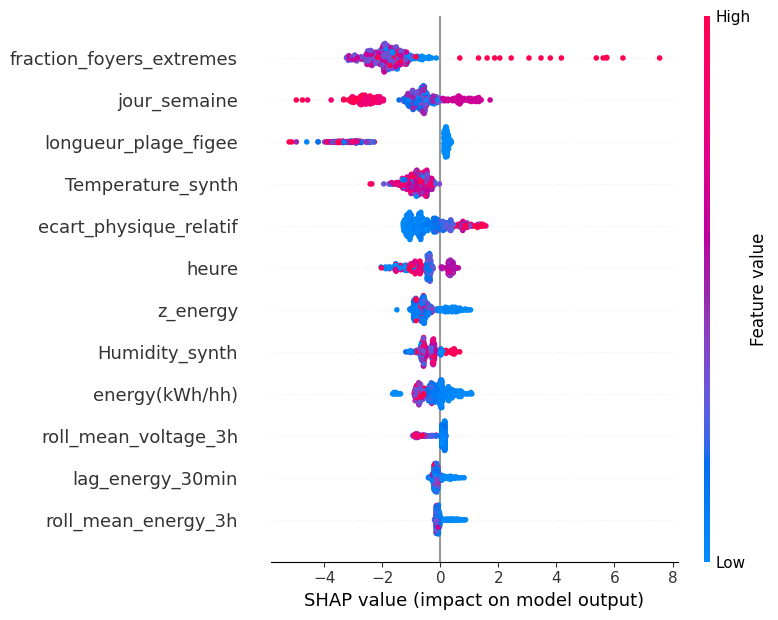

In [ ]:
mask_anom_sub = (df_train['sous_split'] == 'sub_train') & (df_train['anomaly_type'] != 'none')
mask_anom_val = (df_train['sous_split'] == 'val') & (df_train['anomaly_type'] != 'none')
mask_anom_test = df_test['anomaly_type'] != 'none'

X_sub_B = df_train.loc[mask_anom_sub, FEATURES]
y_sub_B = (df_train.loc[mask_anom_sub, 'anomaly_type'] == 'genuine_event').astype(int)
X_val_B = df_train.loc[mask_anom_val, FEATURES]
y_val_B = (df_train.loc[mask_anom_val, 'anomaly_type'] == 'genuine_event').astype(int)
X_test_B = df_test.loc[mask_anom_test, FEATURES]
y_test_B = (df_test.loc[mask_anom_test, 'anomaly_type'] == 'genuine_event').astype(int)

poids_B = compute_sample_weight('balanced', y_sub_B)

print("Effectifs anomalies — sub_train:", len(y_sub_B), " val:", len(y_val_B), " test:", len(y_test_B))
print("Taux genuine_event — sub_train:", y_sub_B.mean(), " val:", y_val_B.mean(), " test:", y_test_B.mean())

candidats_B, meilleur_B, seuil_B, resultats_B = entrainer_comparer_optimiser(
    X_sub_B, y_sub_B, X_val_B, y_val_B, X_test_B, y_test_B,
    type_tache='binaire', poids_sub=poids_B, nom_but="Étage B — Genuine vs Data-Quality",
    seuil_par_fpr=0.05)

Étage C : classification du type précis (parmi les data-quality issues)

Effectifs — sub_train: 37687  val: 4730  test: 9258
[Étage C — Type de défaut] Meilleurs paramètres XGBoost : {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05}
[Étage C — Type de défaut] Meilleurs paramètres CatBoost : {'learning_rate': 0.05, 'iterations': 200, 'depth': 4}

[Étage C — Type de défaut] Scores F1 sur validation : {'XGBoost': 0.551, 'CatBoost': 0.819, 'Random Forest': 0.588, 'Soft Voting': 0.646, 'Stacking': 0.663}
[Étage C — Type de défaut] Modèle retenu : CatBoost

=== Étage C — Type de défaut — TEST (modèle : CatBoost) ===
                     precision    recall  f1-score   support

     biased_reading       0.83      0.92      0.87      3447
corrupted_falsified       0.90      0.61      0.73       937
    degraded_sensor       0.94      0.89      0.92      2427
    equipment_fault       0.92      0.94      0.93      1879
    natural_failure       0.87      0.92      0.89       568

           accuracy                           0.88      9258
          macro

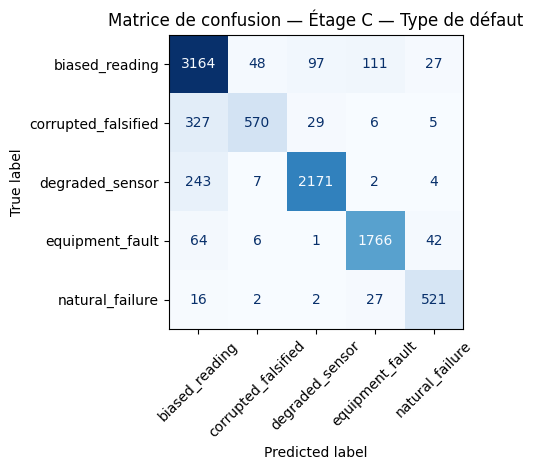

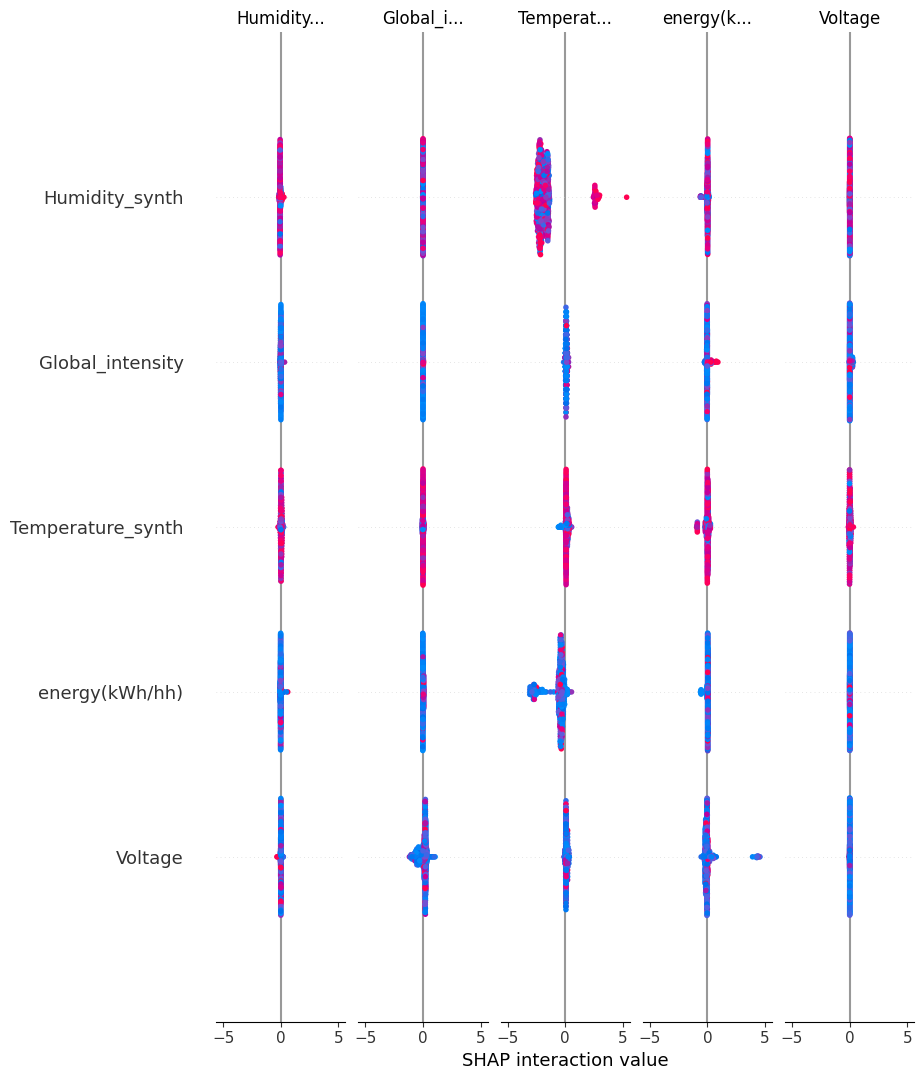

In [ ]:
categories_dq = ['equipment_fault', 'degraded_sensor', 'biased_reading', 'corrupted_falsified', 'natural_failure']

mask_dq_sub = (df_train['sous_split'] == 'sub_train') & df_train['anomaly_type'].isin(categories_dq)
mask_dq_val = (df_train['sous_split'] == 'val') & df_train['anomaly_type'].isin(categories_dq)
mask_dq_test = df_test['anomaly_type'].isin(categories_dq)

encodeur_type = LabelEncoder()
encodeur_type.fit(categories_dq)

X_sub_C = df_train.loc[mask_dq_sub, FEATURES]
y_sub_C = encodeur_type.transform(df_train.loc[mask_dq_sub, 'anomaly_type'])
X_val_C = df_train.loc[mask_dq_val, FEATURES]
y_val_C = encodeur_type.transform(df_train.loc[mask_dq_val, 'anomaly_type'])
X_test_C = df_test.loc[mask_dq_test, FEATURES]
y_test_C = encodeur_type.transform(df_test.loc[mask_dq_test, 'anomaly_type'])

poids_C = compute_sample_weight('balanced', y_sub_C)

print("Effectifs — sub_train:", len(y_sub_C), " val:", len(y_val_C), " test:", len(y_test_C))

candidats_C, meilleur_C, _, resultats_C = entrainer_comparer_optimiser(
    X_sub_C, y_sub_C, X_val_C, y_val_C, X_test_C, y_test_C,
    type_tache='multiclasse', noms_classes=encodeur_type.classes_, poids_sub=poids_C,
    nom_but="Étage C — Type de défaut")

Modéles DL

Reconstruction des tenseurs avec split à 3 niveaux et label de type par fenêtre

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks, regularizers
import numpy as np

VAL_START = pd.Timestamp('2013-10-01')
DATE_SPLIT = pd.Timestamp('2013-11-28')

df_full['sous_split_fenetre'] = np.select(
    [df_full['tstp'] < VAL_START, df_full['tstp'] < DATE_SPLIT],
    ['sub_train', 'val'], default='test')

CANAUX = ['energy(kWh/hh)', 'Voltage', 'Global_intensity', 'Temperature_synth', 'Humidity_synth']
LONGUEUR_FENETRE = 48
STRIDE = 24
categories_dq = ['equipment_fault', 'degraded_sensor', 'biased_reading', 'corrupted_falsified', 'natural_failure']

def construire_fenetres_v2(df_foyer):
    valeurs = df_foyer[CANAUX].to_numpy()
    labels_dq = df_foyer['anomaly_type'].isin(categories_dq).to_numpy()
    labels_genuine = (df_foyer['anomaly_type'] == 'genuine_event').to_numpy()
    types_bruts = df_foyer['anomaly_type'].to_numpy()
    splits = df_foyer['sous_split_fenetre'].to_numpy()

    fenetres, y_dq, y_genuine, y_type, split_f = [], [], [], [], []

    for depart in range(0, len(df_foyer) - LONGUEUR_FENETRE + 1, STRIDE):
        fin = depart + LONGUEUR_FENETRE
        fenetres.append(valeurs[depart:fin])
        y_dq.append(labels_dq[depart:fin].any())
        y_genuine.append(labels_genuine[depart:fin].any())

        types_dq_fenetre = types_bruts[depart:fin][labels_dq[depart:fin]]
        y_type.append(pd.Series(types_dq_fenetre).mode()[0] if len(types_dq_fenetre) > 0 else 'none')

        s = splits[depart:fin]
        split_f.append(s[0] if (s == s[0]).all() else 'mixte')

    return fenetres, y_dq, y_genuine, y_type, split_f

toutes_fenetres, tous_dq, tous_genuine, tous_type, tous_split = [], [], [], [], []

for foyer, groupe in df_full.groupby('LCLid'):
    groupe = groupe.sort_values('tstp')
    f, ydq, yg, yt, sp = construire_fenetres_v2(groupe)
    toutes_fenetres.extend(f)
    tous_dq.extend(ydq)
    tous_genuine.extend(yg)
    tous_type.extend(yt)
    tous_split.extend(sp)

X = np.array(toutes_fenetres)
y_dq = np.array(tous_dq)
y_genuine = np.array(tous_genuine)
y_type = np.array(tous_type)
splits_array = np.array(tous_split)

print("Shape tenseur :", X.shape)
print(pd.Series(splits_array).value_counts())

Shape tenseur : (39014, 48, 5)
sub_train    26736
test          7472
val           4703
mixte          103
Name: count, dtype: int64


Normalisation (fit sur sub_train normal uniquement)

In [ ]:
mask_normal_sub = (splits_array == 'sub_train') & (~y_dq) & (~y_genuine)
X_normal_sub = X[mask_normal_sub]

moyenne_c = X_normal_sub.reshape(-1, len(CANAUX)).mean(axis=0)
ecart_c = X_normal_sub.reshape(-1, len(CANAUX)).std(axis=0)

X_norm = (X - moyenne_c) / ecart_c

mask_sub, mask_val, mask_test = splits_array == 'sub_train', splits_array == 'val', splits_array == 'test'
print("sub_train:", mask_sub.sum(), " val:", mask_val.sum(), " test:", mask_test.sum())

sub_train: 26736  val: 4703  test: 7472


4 architectures DL comparables

In [ ]:
def construire_modele(architecture, n_pas, n_canaux, n_sorties, activation_sortie):
    entree = layers.Input(shape=(n_pas, n_canaux))

    if architecture == 'LSTM':
        x = layers.LSTM(48, return_sequences=False)(entree)
    elif architecture == 'GRU':
        x = layers.GRU(48, return_sequences=False)(entree)
    elif architecture == 'CNN1D':
        x = layers.Conv1D(32, 5, activation='relu', padding='same')(entree)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(64, 5, activation='relu', padding='same')(x)
        x = layers.GlobalAveragePooling1D()(x)
    elif architecture == 'ResNet1D':
        def bloc_residuel(entree_bloc, filtres):
            x = layers.Conv1D(filtres, 3, padding='same', activation='relu')(entree_bloc)
            x = layers.Conv1D(filtres, 3, padding='same')(x)
            raccourci = entree_bloc
            if entree_bloc.shape[-1] != filtres:
                raccourci = layers.Conv1D(filtres, 1, padding='same')(entree_bloc)
            x = layers.Add()([x, raccourci])
            return layers.Activation('relu')(x)
        x = bloc_residuel(entree, 32)
        x = layers.MaxPooling1D(2)(x)
        x = bloc_residuel(x, 64)
        x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    sortie = layers.Dense(n_sorties, activation=activation_sortie)(x)

    modele = Model(entree, sortie)
    return modele

Harnais générique DL (entraînement, sélection, calibration, évaluation, saillance)

In [ ]:
def entrainer_comparer_dl(X_sub, y_sub, X_val, y_val, X_test, y_test,
                           type_tache, noms_classes=None, poids_sub=None, nom_but="", seuil_par_fpr=None):
    n_pas, n_canaux = X_sub.shape[1], X_sub.shape[2]

    if type_tache == 'binaire':
        n_sorties, activation, perte = 1, 'sigmoid', 'binary_crossentropy'
        y_sub_prep, y_val_prep = y_sub.astype(float), y_val.astype(float)
    else:
        n_sorties, activation, perte = len(noms_classes), 'softmax', 'sparse_categorical_crossentropy'
        y_sub_prep, y_val_prep = y_sub, y_val

    candidats, historiques = {}, {}
    for archi in ['LSTM', 'GRU', 'CNN1D', 'ResNet1D']:
        print(f"--- Entraînement {archi} ---")
        modele = construire_modele(archi, n_pas, n_canaux, n_sorties, activation)
        modele.compile(optimizer='adam', loss=perte, metrics=['accuracy'])
        arret = callbacks.EarlyStopping(patience=5, restore_best_weights=True)
        hist = modele.fit(X_sub, y_sub_prep, sample_weight=poids_sub,
                           validation_data=(X_val, y_val_prep),
                           epochs=25, batch_size=256, callbacks=[arret], verbose=0)
        candidats[archi] = modele
        historiques[archi] = hist

    scores_val = {}
    for archi, modele in candidats.items():
        if type_tache == 'binaire':
            pred_val = (modele.predict(X_val, verbose=0).ravel() > 0.5)
            score = f1_score(y_val, pred_val, zero_division=0)
        else:
            pred_val = modele.predict(X_val, verbose=0).argmax(axis=1)
            score = f1_score(y_val, pred_val, average='macro', zero_division=0)
        scores_val[archi] = score
    print(f"\n[{nom_but}] Scores F1 validation :", {k: round(v, 3) for k, v in scores_val.items()})
    meilleur_nom = max(scores_val, key=scores_val.get)
    print(f"[{nom_but}] Architecture retenue : {meilleur_nom}")
    meilleur_modele = candidats[meilleur_nom]

    seuil_optimal = 0.5
    if type_tache == 'binaire':
        proba_val = meilleur_modele.predict(X_val, verbose=0).ravel()
        if seuil_par_fpr is not None:
            seuil_optimal, fpr_o, tpr_o = seuil_par_fpr_cible(y_val, proba_val, seuil_par_fpr)
            print(f"[{nom_but}] Seuil (FPR cible={seuil_par_fpr}) : {seuil_optimal:.3f} (FPR={fpr_o:.3f}, TPR={tpr_o:.3f})")
        else:
            seuils_essai = np.linspace(0.05, 0.95, 50)
            f1s = [f1_score(y_val, proba_val > s, zero_division=0) for s in seuils_essai]
            seuil_optimal = seuils_essai[np.argmax(f1s)]
            print(f"[{nom_but}] Seuil optimal (F1) : {seuil_optimal:.2f}")

        proba_test = meilleur_modele.predict(X_test, verbose=0).ravel()
        pred_test = proba_test > seuil_optimal
        evaluer_binaire(y_test, pred_test, proba_test, f"{nom_but} — {meilleur_nom} (seuil={seuil_optimal:.3f})")
    else:
        proba_test = meilleur_modele.predict(X_test, verbose=0)
        pred_test = proba_test.argmax(axis=1)
        print(f"\n=== {nom_but} — TEST ({meilleur_nom}) ===")
        print(classification_report(y_test, pred_test, target_names=noms_classes, zero_division=0))
        cm = confusion_matrix(y_test, pred_test)
        ConfusionMatrixDisplay(cm, display_labels=noms_classes).plot(xticks_rotation=45, cmap='Blues', colorbar=False)
        plt.title(f"Matrice de confusion — {nom_but}"); plt.tight_layout(); plt.show()

    # Courbes d'apprentissage du modèle retenu
    hist = historiques[meilleur_nom]
    plt.figure(figsize=(6, 4))
    plt.plot(hist.history['loss'], label='train')
    plt.plot(hist.history['val_loss'], label='val')
    plt.title(f"Courbe d'apprentissage — {meilleur_nom}"); plt.legend(); plt.show()

    return candidats, meilleur_nom, seuil_optimal, meilleur_modele


def expliquer_par_saillance(modele, x_exemple, canaux, classe_cible=None):
    x_tensor = tf.convert_to_tensor(x_exemple[np.newaxis, ...], dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        sortie = modele(x_tensor)
        cible = sortie[0, 0] if classe_cible is None else sortie[0, classe_cible]
    gradients = tape.gradient(cible, x_tensor)[0].numpy()
    saillance = np.abs(gradients * x_exemple)

    plt.figure(figsize=(12, 4))
    plt.imshow(saillance.T, aspect='auto', cmap='hot')
    plt.yticks(range(len(canaux)), canaux)
    plt.xlabel("Pas de temps dans la fenêtre (48 = 1 jour)")
    plt.title("Saillance (gradient × entrée) — quel canal/instant a le plus influencé la décision")
    plt.colorbar(label="Importance")
    plt.show()

Étage A DL (détection globale)

--- Entraînement LSTM ---
--- Entraînement GRU ---
--- Entraînement CNN1D ---
--- Entraînement ResNet1D ---

[Étage A DL — Détection globale] Scores F1 validation : {'LSTM': 0.712, 'GRU': 0.776, 'CNN1D': 0.748, 'ResNet1D': 0.806}
[Étage A DL — Détection globale] Architecture retenue : ResNet1D
[Étage A DL — Détection globale] Seuil optimal (F1) : 0.62
[Étage A DL — Détection globale — ResNet1D (seuil=0.619)] précision=0.889  rappel=0.658  F1=0.756


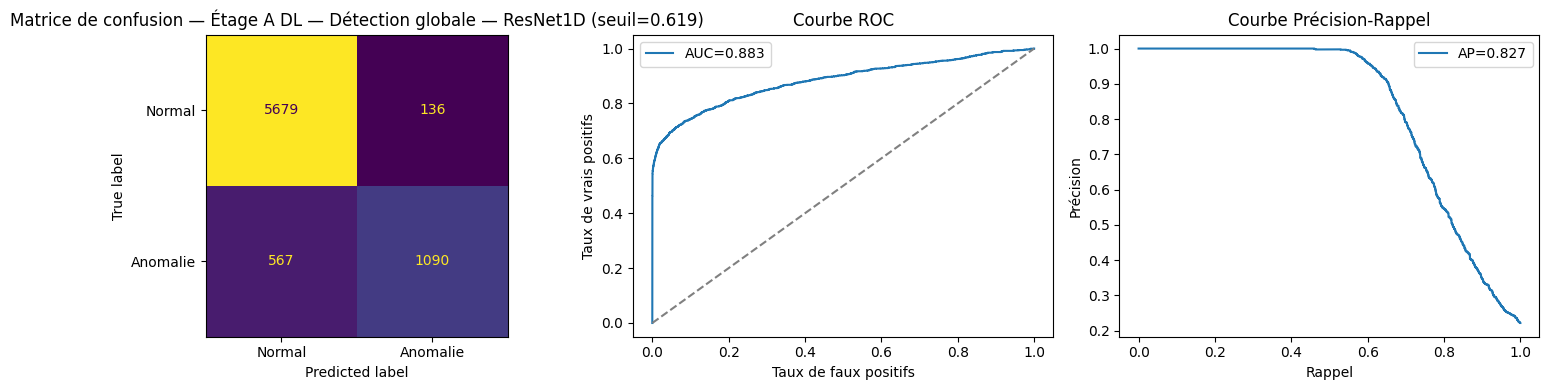

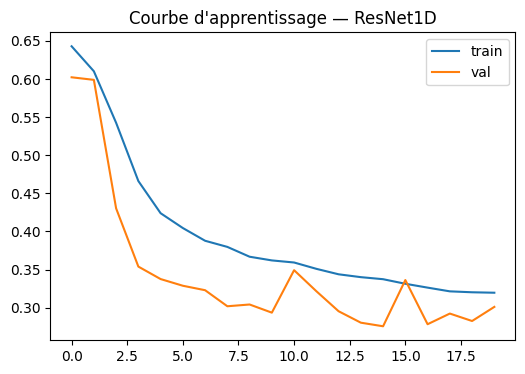

In [ ]:
poids_A_dl = compute_sample_weight('balanced', (y_dq[mask_sub] | y_genuine[mask_sub]).astype(int))

candidats_A_dl, meilleur_A_dl, seuil_A_dl, modele_A_dl = entrainer_comparer_dl(
    X_norm[mask_sub], (y_dq[mask_sub] | y_genuine[mask_sub]).astype(int),
    X_norm[mask_val], (y_dq[mask_val] | y_genuine[mask_val]).astype(int),
    X_norm[mask_test], (y_dq[mask_test] | y_genuine[mask_test]).astype(int),
    type_tache='binaire', poids_sub=poids_A_dl, nom_but="Étage A DL — Détection globale")

Étage B DL (genuine vs data-quality, parmi les fenêtres anormales)

--- Entraînement LSTM ---
--- Entraînement GRU ---
--- Entraînement CNN1D ---
--- Entraînement ResNet1D ---

[Étage B DL — Genuine vs Data-Quality] Scores F1 validation : {'LSTM': 0.281, 'GRU': 0.318, 'CNN1D': 0.194, 'ResNet1D': 0.237}
[Étage B DL — Genuine vs Data-Quality] Architecture retenue : GRU
[Étage B DL — Genuine vs Data-Quality] Seuil (FPR cible=0.05) : 0.644 (FPR=0.050, TPR=0.025)
[Étage B DL — Genuine vs Data-Quality — GRU (seuil=0.644)] précision=0.132  rappel=0.740  F1=0.224


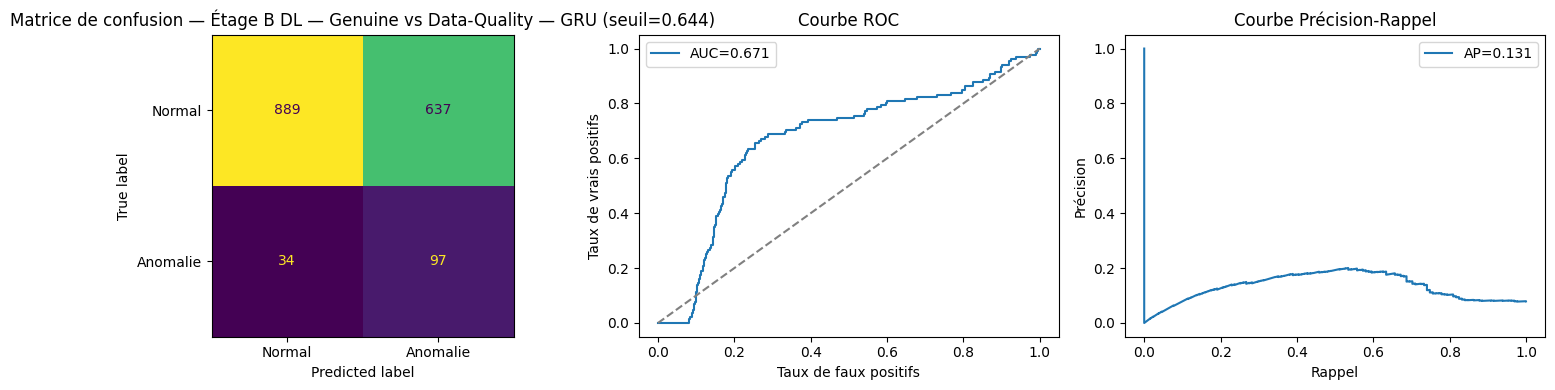

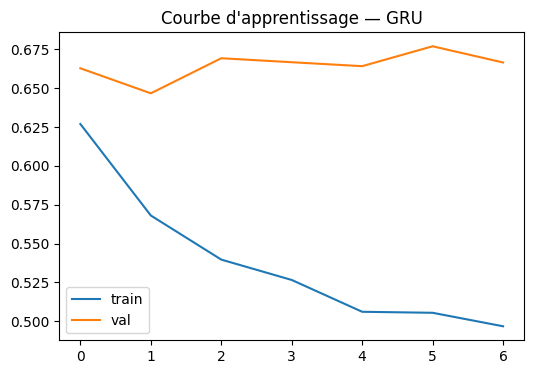

In [ ]:
mask_anom_sub_dl = mask_sub & (y_dq | y_genuine)
mask_anom_val_dl = mask_val & (y_dq | y_genuine)
mask_anom_test_dl = mask_test & (y_dq | y_genuine)

poids_B_dl = compute_sample_weight('balanced', y_genuine[mask_anom_sub_dl].astype(int))

candidats_B_dl, meilleur_B_dl, seuil_B_dl, modele_B_dl = entrainer_comparer_dl(
    X_norm[mask_anom_sub_dl], y_genuine[mask_anom_sub_dl].astype(int),
    X_norm[mask_anom_val_dl], y_genuine[mask_anom_val_dl].astype(int),
    X_norm[mask_anom_test_dl], y_genuine[mask_anom_test_dl].astype(int),
    type_tache='binaire', poids_sub=poids_B_dl, nom_but="Étage B DL — Genuine vs Data-Quality",
    seuil_par_fpr=0.05)

Étage C DL (type précis, parmi les fenêtres data-quality)

--- Entraînement LSTM ---
--- Entraînement GRU ---
--- Entraînement CNN1D ---
--- Entraînement ResNet1D ---

[Étage C DL — Type de défaut] Scores F1 validation : {'LSTM': 0.352, 'GRU': 0.32, 'CNN1D': 0.458, 'ResNet1D': 0.477}
[Étage C DL — Type de défaut] Architecture retenue : ResNet1D

=== Étage C DL — Type de défaut — TEST (ResNet1D) ===
                     precision    recall  f1-score   support

     biased_reading       0.73      0.07      0.12       163
corrupted_falsified       0.75      0.83      0.79       818
    degraded_sensor       0.99      0.89      0.94       128
    equipment_fault       0.61      0.49      0.54       219
    natural_failure       0.61      0.94      0.74       221

           accuracy                           0.72      1549
          macro avg       0.74      0.64      0.63      1549
       weighted avg       0.73      0.72      0.69      1549



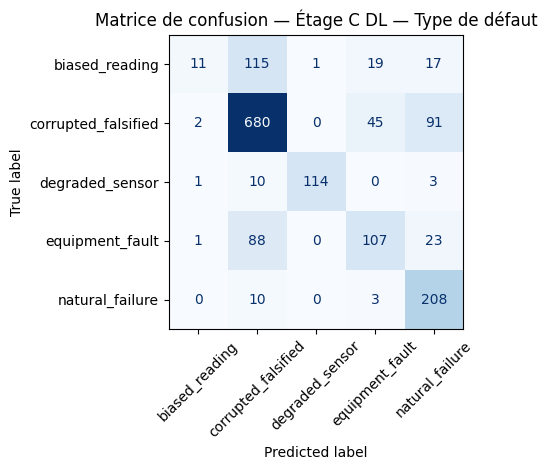

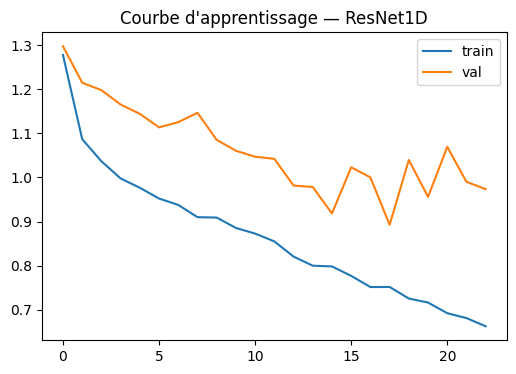

In [ ]:
mask_dq_sub_dl = mask_sub & y_dq
mask_dq_val_dl = mask_val & y_dq
mask_dq_test_dl = mask_test & y_dq

encodeur_type_dl = LabelEncoder()
encodeur_type_dl.fit(categories_dq)

y_sub_C_dl = encodeur_type_dl.transform(y_type[mask_dq_sub_dl])
y_val_C_dl = encodeur_type_dl.transform(y_type[mask_dq_val_dl])
y_test_C_dl = encodeur_type_dl.transform(y_type[mask_dq_test_dl])

poids_C_dl = compute_sample_weight('balanced', y_sub_C_dl)

candidats_C_dl, meilleur_C_dl, _, modele_C_dl = entrainer_comparer_dl(
    X_norm[mask_dq_sub_dl], y_sub_C_dl, X_norm[mask_dq_val_dl], y_val_C_dl,
    X_norm[mask_dq_test_dl], y_test_C_dl,
    type_tache='multiclasse', noms_classes=encodeur_type_dl.classes_, poids_sub=poids_C_dl,
    nom_but="Étage C DL — Type de défaut")

Exemple d'explicabilité par saillance (Étage A)

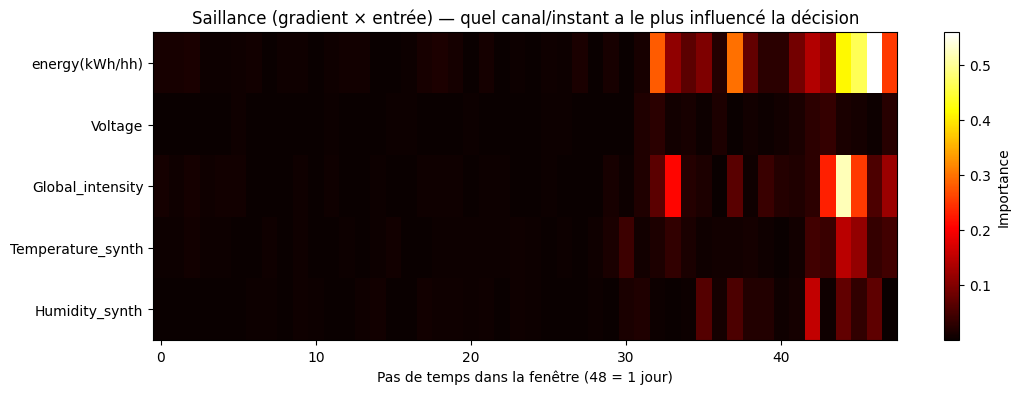

In [ ]:
idx_positif = np.where(mask_test & (y_dq | y_genuine))[0][0]
expliquer_par_saillance(modele_A_dl, X_norm[idx_positif], CANAUX)

Score de confiance unifié

In [ ]:
def score_confiance_unifie(df_lignes, modele_A, seuil_A, modele_B, seuil_B, modele_C, encodeur_C, features):
    X = df_lignes[features]

    proba_A = modele_A.predict_proba(X)[:, 1]
    est_anormal = proba_A > seuil_A

    proba_B = np.full(len(df_lignes), np.nan)
    verdict_genuine = np.full(len(df_lignes), False)
    proba_C = np.full(len(df_lignes), np.nan)
    type_predit = np.full(len(df_lignes), 'none', dtype=object)

    idx_anormal = np.where(est_anormal)[0]
    if len(idx_anormal) > 0:
        X_anormal = X.iloc[idx_anormal]
        proba_B[idx_anormal] = modele_B.predict_proba(X_anormal)[:, 1]
        verdict_genuine[idx_anormal] = proba_B[idx_anormal] > seuil_B

        idx_dq = idx_anormal[~verdict_genuine[idx_anormal]]
        if len(idx_dq) > 0:
            X_dq = X.iloc[idx_dq]
            proba_C_matrice = modele_C.predict_proba(X_dq)
            proba_C[idx_dq] = proba_C_matrice.max(axis=1)
            type_predit[idx_dq] = encodeur_C.inverse_transform(proba_C_matrice.argmax(axis=1))

    verdict = np.where(~est_anormal, 'normal',
               np.where(verdict_genuine, 'genuine_event', type_predit))

    # Score de confiance unifié (0-100%) : combine la certitude de chaque étage franchi
    confiance = np.where(~est_anormal, (1 - proba_A) * 100,
                 np.where(verdict_genuine, ((proba_A + proba_B) / 2) * 100,
                          ((proba_A + (1 - proba_B) + np.nan_to_num(proba_C, nan=0.5)) / 3) * 100))

    resultats = df_lignes[['LCLid', 'tstp']].copy()
    resultats['proba_etage_A'] = proba_A
    resultats['proba_etage_B_genuine'] = proba_B
    resultats['proba_etage_C_type'] = proba_C
    resultats['verdict'] = verdict
    resultats['confiance_pct'] = confiance.round(1)
    return resultats

resultats_confiance = score_confiance_unifie(
    df_test, candidats_A[meilleur_A], seuil_A, candidats_B[meilleur_B], seuil_B,
    candidats_C[meilleur_C], encodeur_type, FEATURES)

print(resultats_confiance['verdict'].value_counts())
print(resultats_confiance[resultats_confiance['verdict'] != 'normal']['confiance_pct'].describe())

verdict
normal                 175254
degraded_sensor          2072
equipment_fault          1790
natural_failure           526
corrupted_falsified       500
biased_reading            321
genuine_event             146
Name: count, dtype: int64
count    5355.000000
mean       89.833856
std        13.855803
min        33.800000
25%        87.800000
50%        96.400000
75%        98.600000
max        99.700000
Name: confiance_pct, dtype: float64


Explication en langage clair

In [ ]:
def generer_explication(ligne_df, ligne_resultat, seuil_z_energy, seuil_z_voltage, seuil_ratio_persistance):
    verdict = ligne_resultat['verdict']
    if verdict == 'normal':
        return "Aucune anomalie détectée, comportement cohérent avec l'historique de ce foyer."

    raisons = []
    if abs(ligne_df['z_energy']) > seuil_z_energy:
        raisons.append(f"consommation à {ligne_df['z_energy']:.1f} écarts-types de l'habitude de ce foyer")
    if abs(ligne_df['z_voltage']) > seuil_z_voltage:
        raisons.append(f"tension anormale ({ligne_df['Voltage']:.1f}V, écart {ligne_df['z_voltage']:.1f}σ)")
    if ligne_df['longueur_plage_figee'] >= 8:
        raisons.append(f"valeur figée depuis {int(ligne_df['longueur_plage_figee'] * 0.5)}h")
    if ligne_df['ratio_persistance'] > seuil_ratio_persistance:
        raisons.append("décalage soutenu sur plusieurs jours, pas un pic isolé")
    if ligne_df['fraction_foyers_extremes'] > 0.05:
        raisons.append(f"{ligne_df['fraction_foyers_extremes']*100:.0f}% des foyers du quartier affectés simultanément")

    texte_raisons = " ; ".join(raisons) if raisons else "déviation statistique générale"

    if verdict == 'genuine_event':
        conclusion = "Interprété comme un événement réseau réel (plusieurs foyers concernés simultanément) — nécessite une réponse opérationnelle, pas une correction de données."
    else:
        libelle_type = {
            'equipment_fault': "panne de compteur (valeur figée)",
            'degraded_sensor': "dérive de calibration du capteur de tension",
            'biased_reading': "biais de mesure constant",
            'corrupted_falsified': "lecture corrompue ou falsifiée ponctuelle",
            'natural_failure': "panne physique liée à un contexte météo extrême"
        }.get(verdict, verdict)
        conclusion = f"Interprété comme un problème de données ({libelle_type}) — foyer isolé, pas de corrélation avec les voisins."

    return (f"Foyer {ligne_df['LCLid']}, {ligne_df['tstp']} : {texte_raisons}. "
            f"{conclusion} Confiance : {ligne_resultat['confiance_pct']:.0f}%.")


exemples_flagged = resultats_confiance[resultats_confiance['verdict'] != 'normal'].sample(
    min(5, (resultats_confiance['verdict'] != 'normal').sum()), random_state=42)

for idx in exemples_flagged.index:
    print(generer_explication(df_test.loc[idx], resultats_confiance.loc[idx],
                               seuil_z_energy=seuil_z_energy, seuil_z_voltage=seuil_z_voltage,
                               seuil_ratio_persistance=df_train[df_train['anomaly_type']=='none']['ratio_persistance'].quantile(0.99)))
    print()

Foyer MAC004387, 2014-01-09 12:00:00 : déviation statistique générale. Interprété comme un problème de données (dérive de calibration du capteur de tension) — foyer isolé, pas de corrélation avec les voisins. Confiance : 95%.

Foyer MAC003553, 2013-11-28 20:00:00 : déviation statistique générale. Interprété comme un problème de données (panne de compteur (valeur figée)) — foyer isolé, pas de corrélation avec les voisins. Confiance : 89%.

Foyer MAC003239, 2014-02-08 01:30:00 : valeur figée depuis 15h. Interprété comme un problème de données (panne de compteur (valeur figée)) — foyer isolé, pas de corrélation avec les voisins. Confiance : 99%.

Foyer MAC004179, 2013-12-24 01:00:00 : 17% des foyers du quartier affectés simultanément. Interprété comme un problème de données (dérive de calibration du capteur de tension) — foyer isolé, pas de corrélation avec les voisins. Confiance : 80%.

Foyer MAC003553, 2014-01-21 06:30:00 : déviation statistique générale. Interprété comme un problème de

Log de décision auditable

In [ ]:
def construire_log_decision(df_lignes, resultats):
    log = resultats.copy()
    log['explication'] = [
        generer_explication(df_lignes.loc[idx], resultats.loc[idx],
                             seuil_z_energy, seuil_z_voltage,
                             df_train[df_train['anomaly_type']=='none']['ratio_persistance'].quantile(0.99))
        for idx in resultats.index
    ]
    log['modele_etage_A'] = meilleur_A
    log['modele_etage_B'] = meilleur_B
    log['modele_etage_C'] = meilleur_C
    log['horodatage_evaluation'] = pd.Timestamp.now()
    return log

log_decision = construire_log_decision(df_test, resultats_confiance)

log_decision.to_csv(base + 'log_decision_test.csv', index=False)
print(log_decision.shape)
print(log_decision[log_decision['verdict'] != 'normal'][['LCLid', 'tstp', 'verdict', 'confiance_pct', 'explication']].head(3))

Logique d'escalade humain-IA

In [ ]:
def action_recommandee(verdict, confiance):
    if verdict == 'normal':
        return 'aucune_action'
    if verdict == 'genuine_event':
        return 'alerte_operateur_immediate'  # jamais d'auto-résolution sur un vrai événement réseau
    if verdict in ['corrupted_falsified', 'equipment_fault']:
        # défauts avec une correction automatique simple et réversible possible (exclure/interpoler la lecture)
        return 'auto_resolution' if confiance >= 75 else 'revue_humaine'
    if verdict in ['degraded_sensor', 'biased_reading']:
        # nécessitent une intervention physique (recalibration), jamais d'auto-résolution pure
        return 'intervention_technicien' if confiance >= 60 else 'revue_humaine'
    if verdict == 'natural_failure':
        return 'revue_humaine'
    return 'revue_humaine'

log_decision['action_recommandee'] = [
    action_recommandee(v, c) for v, c in zip(log_decision['verdict'], log_decision['confiance_pct'])
]

print(log_decision[log_decision['verdict'] != 'normal']['action_recommandee'].value_counts())

In [ ]:
# Garde-fou contre le sur-confiance (over-trust) : audit aléatoire obligatoire même sur les cas auto-résolus
np.random.seed(42)
mask_auto = log_decision['action_recommandee'] == 'auto_resolution'
log_decision['audit_aleatoire_requis'] = False
log_decision.loc[mask_auto, 'audit_aleatoire_requis'] = np.random.random(mask_auto.sum()) < 0.05  # 5% échantillonné

print("Cas auto-résolus :", mask_auto.sum(), " — dont audités aléatoirement :", log_decision['audit_aleatoire_requis'].sum())

In [ ]:
# Garde-fou contre le sous-confiance (under-trust) : courbe de calibration pour montrer que la confiance affichée
# reflète bien le taux de réussite réel, condition nécessaire pour que l'opérateur fasse confiance au score
from sklearn.calibration import calibration_curve

y_vrai_anomalie = (df_test['anomaly_type'] != 'none').astype(int)
proba_pour_calibration = resultats_confiance['proba_etage_A']

frac_positifs, moyenne_predite = calibration_curve(y_vrai_anomalie, proba_pour_calibration, n_bins=10)

plt.figure(figsize=(6, 5))
plt.plot(moyenne_predite, frac_positifs, marker='o', label='Modèle Étage A')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Calibration parfaite')
plt.xlabel("Confiance moyenne prédite"); plt.ylabel("Taux réel d'anomalies")
plt.title("Courbe de calibration — la confiance affichée est-elle fiable ?")
plt.legend(); plt.show()